<a href="https://colab.research.google.com/github/muzamil-saleem/XAI_LLM_IDS/blob/main/04_revision_extras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 04 — Revision Extras
Computes everything the reviewer asked for that wasn't in notebooks 00–03:
1. **MCC** (Matthews Correlation Coefficient) for all 4 models
2. **PR-AUC** (Average Precision) table for DistilBERT
3. **Bootstrap 95% CIs** on macro F1 for all 4 models
4. **Token-length distribution** histogram
5. **Majority-class baseline** for CIC-IDS2017 zero-shot

**Runtime:** < 5 minutes on any GPU. No model retraining.

In [ ]:
# ── Cell 1: Mount Drive and load saved predictions ──────────
import os, json
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/XAI_LLM_IDS/'

le      = joblib.load(BASE + 'models/label_encoder.pkl')
CLASSES = list(le.classes_)
fc      = json.load(open(BASE + 'data/feat_cols.json'))
FEATS   = fc['FEATS']

y_te    = np.load(BASE + 'predictions/y_test.npy')
y_pred  = np.load(BASE + 'predictions/y_pred.npy')
y_cnn   = np.load(BASE + 'predictions/cnn_preds.npy')
y_lstm  = np.load(BASE + 'predictions/lstm_preds.npy')
y_rob   = np.load(BASE + 'predictions/roberta_preds.npy')
y_proba = np.load(BASE + 'predictions/y_proba.npy')

test_df = pd.read_pickle(BASE + 'data/test_preprocessed.pkl')

print(f'Test samples: {len(y_te):,}')
print(f'Classes: {CLASSES}')
print('All predictions loaded.')

Mounted at /content/drive
Test samples: 82,332
Classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
All predictions loaded.


## 1. Matthews Correlation Coefficient (Reviewer Point 9)

In [ ]:
# ── Cell 2: MCC for all 4 models ──────────────────────────
from sklearn.metrics import matthews_corrcoef, f1_score

models = {
    'CNN':       y_cnn,
    'LSTM':      y_lstm,
    'RoBERTa':   y_rob,
    'DistilBERT': y_pred,
}

mcc_results = []
for name, preds in models.items():
    mcc = matthews_corrcoef(y_te, preds)
    f1  = f1_score(y_te, preds, average='macro')
    mcc_results.append({
        'Model': name,
        'Macro F1': round(f1, 4),
        'MCC': round(mcc, 4),
    })
    print(f'{name:12s}  Macro F1 = {f1:.4f}   MCC = {mcc:.4f}')

mcc_df = pd.DataFrame(mcc_results)
os.makedirs(BASE + 'paper_tables/', exist_ok=True)
mcc_df.to_csv(BASE + 'paper_tables/mcc_scores.csv', index=False)
print('\nMCC scores saved.')

CNN           Macro F1 = 0.2751   MCC = 0.4666
LSTM          Macro F1 = 0.2293   MCC = 0.4057
RoBERTa       Macro F1 = 0.4948   MCC = 0.6405
DistilBERT    Macro F1 = 0.5033   MCC = 0.6416

MCC scores saved.


## 2. PR-AUC (Average Precision) Table (Reviewer Point 9)

In [ ]:
# ── Cell 3: Per-class Average Precision for DistilBERT ─────
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize

y_te_bin = label_binarize(y_te, classes=range(10))

ap_results = []
for i, cls_name in enumerate(CLASSES):
    ap = average_precision_score(y_te_bin[:, i], y_proba[:, i])
    ap_results.append({'Class': cls_name, 'Average Precision': round(ap, 4)})
    print(f'{cls_name:15s}  AP = {ap:.4f}')

# Macro average
macro_ap = np.mean([r['Average Precision'] for r in ap_results])
ap_results.append({'Class': 'Macro Average', 'Average Precision': round(macro_ap, 4)})
print(f'{"Macro Average":15s}  AP = {macro_ap:.4f}')

ap_df = pd.DataFrame(ap_results)
ap_df.to_csv(BASE + 'paper_tables/average_precision.csv', index=False)
print('\nAverage Precision table saved.')

Analysis         AP = 0.0468
Backdoor         AP = 0.1172
DoS              AP = 0.3701
Exploits         AP = 0.8207
Fuzzers          AP = 0.4048
Generic          AP = 0.9957
Normal           AP = 0.9725
Reconnaissance   AP = 0.8951
Shellcode        AP = 0.4213
Worms            AP = 0.6110
Macro Average    AP = 0.5655

Average Precision table saved.


## 3. Bootstrap 95% Confidence Intervals (Reviewer Point 4)

In [ ]:
# ── Cell 4: Bootstrap CIs on macro F1 ─────────────────────
from sklearn.metrics import f1_score

np.random.seed(42)
N_BOOT = 1000
n      = len(y_te)

print(f'Running {N_BOOT} bootstrap iterations...\n')

ci_results = []
for name, preds in models.items():
    scores = []
    for _ in range(N_BOOT):
        idx = np.random.choice(n, size=n, replace=True)
        scores.append(f1_score(y_te[idx], preds[idx], average='macro'))

    scores = np.array(scores)
    lo = np.percentile(scores, 2.5)
    hi = np.percentile(scores, 97.5)
    mean = scores.mean()

    ci_results.append({
        'Model': name,
        'Mean F1': round(mean, 4),
        '95% CI Lower': round(lo, 4),
        '95% CI Upper': round(hi, 4),
    })
    print(f'{name:12s}  F1 = {mean:.4f}  [{lo:.4f}, {hi:.4f}]')

ci_df = pd.DataFrame(ci_results)
ci_df.to_csv(BASE + 'paper_tables/bootstrap_ci.csv', index=False)
print('\nBootstrap CIs saved.')

Running 1000 bootstrap iterations...

CNN           F1 = 0.2751  [0.2720, 0.2783]
LSTM          F1 = 0.2293  [0.2273, 0.2313]
RoBERTa       F1 = 0.4945  [0.4831, 0.5046]
DistilBERT    F1 = 0.5030  [0.4916, 0.5136]

Bootstrap CIs saved.


## 4. Token-Length Distribution (Reviewer Point 1)

In [ ]:
# ── Cell 5: Tokenize test set and plot lengths ────────────
!pip install -q transformers
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained(
    BASE + 'models/distilbert_best/')

print('Tokenizing all test records...')
texts = test_df['text'].tolist()

# Tokenize WITHOUT truncation to get true lengths
encodings = tokenizer(
    texts,
    truncation=False,
    padding=False,
    return_length=True,
)
lengths = encodings['length']

lengths = np.array(lengths)
print(f'\nToken-length statistics:')
print(f'  Min:    {lengths.min()}')
print(f'  Max:    {lengths.max()}')
print(f'  Mean:   {lengths.mean():.1f}')
print(f'  Median: {np.median(lengths):.0f}')
print(f'  Std:    {lengths.std():.1f}')
pct_within = (lengths <= 128).sum() / len(lengths) * 100
print(f'  Within 128 tokens: {pct_within:.2f}%')
pct_truncated = (lengths > 128).sum() / len(lengths) * 100
print(f'  Truncated (>128):  {pct_truncated:.2f}% ({(lengths > 128).sum()} records)')

# Save stats
stats = {
    'min': int(lengths.min()),
    'max': int(lengths.max()),
    'mean': round(float(lengths.mean()), 1),
    'median': int(np.median(lengths)),
    'std': round(float(lengths.std()), 1),
    'pct_within_128': round(pct_within, 2),
    'n_truncated': int((lengths > 128).sum()),
    'total': len(lengths),
}
json.dump(stats, open(BASE + 'results/token_length_stats.json', 'w'), indent=2)
print('\nStats saved.')

Tokenizing all test records...

Token-length statistics:
  Min:    215
  Max:    316
  Mean:   274.9
  Median: 277
  Std:    17.6
  Within 128 tokens: 0.00%
  Truncated (>128):  100.00% (82332 records)

Stats saved.


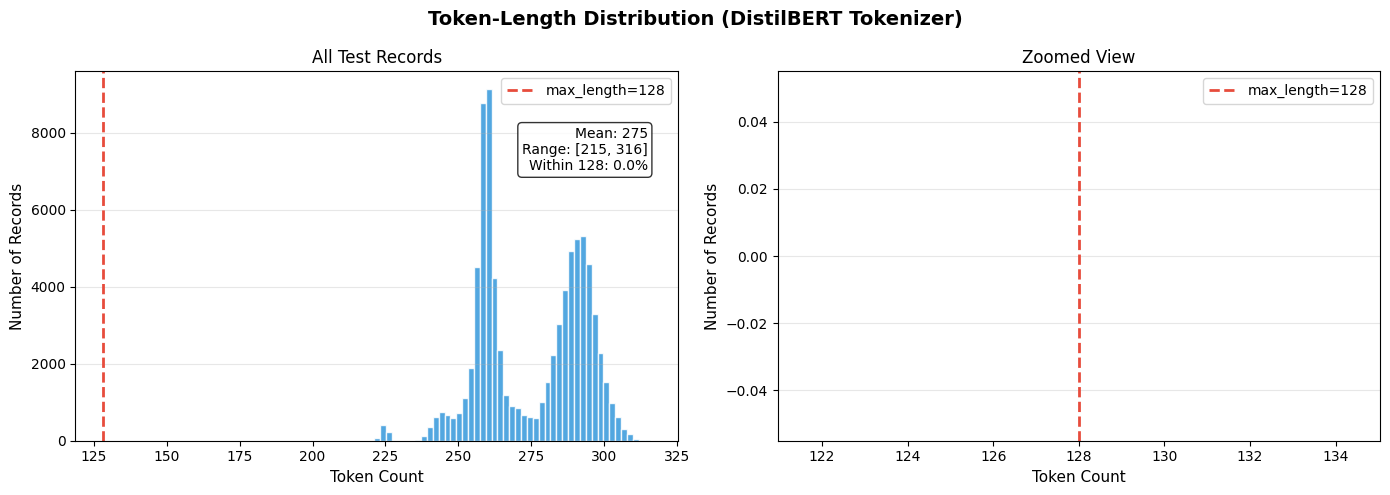

Token-length histogram saved.


In [ ]:
# ── Cell 6: Token-length histogram ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Token-Length Distribution (DistilBERT Tokenizer)',
             fontsize=14, fontweight='bold')

# Left: full histogram
axes[0].hist(lengths, bins=50, color='#3498DB',
             edgecolor='white', alpha=0.85)
axes[0].axvline(x=128, color='#E74C3C', linewidth=2,
                linestyle='--', label='max_length=128')
axes[0].set_title('All Test Records', fontsize=12)
axes[0].set_xlabel('Token Count', fontsize=11)
axes[0].set_ylabel('Number of Records', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Right: zoomed around 128
axes[1].hist(lengths, bins=range(int(lengths.min()),
             min(int(lengths.max()) + 2, 200)),
             color='#2ECC71', edgecolor='white', alpha=0.85)
axes[1].axvline(x=128, color='#E74C3C', linewidth=2,
                linestyle='--', label='max_length=128')
axes[1].set_title('Zoomed View', fontsize=12)
axes[1].set_xlabel('Token Count', fontsize=11)
axes[1].set_ylabel('Number of Records', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# Add annotation
axes[0].text(0.95, 0.85,
    f'Mean: {lengths.mean():.0f}\n'
    f'Range: [{lengths.min()}, {lengths.max()}]\n'
    f'Within 128: {pct_within:.1f}%',
    transform=axes[0].transAxes,
    fontsize=10, verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
os.makedirs(BASE + 'plots/', exist_ok=True)
plt.savefig(BASE + 'plots/fig_token_length_dist.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Token-length histogram saved.')

## 5. Majority-Class Baseline for CIC (Reviewer Point 14)

In [ ]:
# ── Cell 7: CIC majority-class baseline ───────────────────
from sklearn.metrics import f1_score, accuracy_score

# Load CIC predictions
y_cic_labels = np.load(BASE + 'predictions/cic_labels.npy')
y_cic_preds  = np.load(BASE + 'predictions/cic_preds.npy')

# Majority class in CIC sample = Normal (class index for Normal)
normal_idx = list(le.classes_).index('Normal')
y_majority = np.full_like(y_cic_labels, normal_idx)

# Compute baselines
maj_acc    = accuracy_score(y_cic_labels, y_majority)
maj_f1     = f1_score(y_cic_labels, y_majority, average='macro')
model_acc  = accuracy_score(y_cic_labels, y_cic_preds)
model_f1   = f1_score(y_cic_labels, y_cic_preds, average='macro')

print('CIC-IDS2017 Zero-Shot Baselines:')
print(f'  Majority-class (all Normal):')
print(f'    Accuracy = {maj_acc:.4f}')
print(f'    Macro F1 = {maj_f1:.4f}')
print(f'  DistilBERT zero-shot:')
print(f'    Accuracy = {model_acc:.4f}')
print(f'    Macro F1 = {model_f1:.4f}')
print()

# Class distribution
print('CIC sample class distribution:')
for cls_idx in sorted(set(y_cic_labels)):
    count = (y_cic_labels == cls_idx).sum()
    pct   = count / len(y_cic_labels) * 100
    print(f'  {le.classes_[cls_idx]:15s}  {count:6d}  ({pct:.1f}%)')

baseline_data = {
    'majority_accuracy': round(maj_acc, 4),
    'majority_macro_f1': round(maj_f1, 4),
    'model_accuracy': round(model_acc, 4),
    'model_macro_f1': round(model_f1, 4),
    'majority_class': 'Normal',
    'majority_pct': round((y_cic_labels == normal_idx).sum() / len(y_cic_labels) * 100, 1),
}
json.dump(baseline_data, open(BASE + 'results/cic_majority_baseline.json', 'w'), indent=2)
print('\nCIC baseline comparison saved.')

CIC-IDS2017 Zero-Shot Baselines:
  Majority-class (all Normal):
    Accuracy = 0.8311
    Macro F1 = 0.1513
  DistilBERT zero-shot:
    Accuracy = 0.2715
    Macro F1 = 0.0657

CIC sample class distribution:
  DoS                6382  (12.8%)
  Exploits            181  (0.4%)
  Fuzzers              43  (0.1%)
  Generic              39  (0.1%)
  Normal            41556  (83.1%)
  Reconnaissance     1799  (3.6%)

CIC baseline comparison saved.


## 6. Verify All Revision Outputs

In [ ]:
# ── Cell 8: Final check ───────────────────────────────────
revision_files = [
    'paper_tables/mcc_scores.csv',
    'paper_tables/average_precision.csv',
    'paper_tables/bootstrap_ci.csv',
    'results/token_length_stats.json',
    'results/cic_majority_baseline.json',
    'plots/fig_token_length_dist.png',
]

print('=== REVISION EXTRAS VERIFICATION ===\n')
all_ok = True
for f in revision_files:
    path   = BASE + f
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1e3 if exists else 0
    status = f'OK  {size:.0f} KB' if exists else 'MISSING'
    print(f'  {f:45s} {status}')
    if not exists:
        all_ok = False

print()
if all_ok:
    print('All revision extras computed successfully.')
    print('You can now reference these in the revised paper.')
else:
    print('Some files missing. Check errors above.')

# Print summary of results for quick reference
print('\n' + '='*55)
print('RESULTS SUMMARY FOR PAPER REVISION')
print('='*55)

print('\n--- MCC Scores ---')
print(pd.read_csv(BASE + 'paper_tables/mcc_scores.csv').to_string(index=False))

print('\n--- Bootstrap 95% CIs (Macro F1) ---')
print(pd.read_csv(BASE + 'paper_tables/bootstrap_ci.csv').to_string(index=False))

print('\n--- Average Precision (DistilBERT) ---')
print(pd.read_csv(BASE + 'paper_tables/average_precision.csv').to_string(index=False))

print('\n--- Token Length Stats ---')
print(json.dumps(json.load(open(BASE + 'results/token_length_stats.json')), indent=2))

print('\n--- CIC Majority Baseline ---')
print(json.dumps(json.load(open(BASE + 'results/cic_majority_baseline.json')), indent=2))

=== REVISION EXTRAS VERIFICATION ===

  paper_tables/mcc_scores.csv                   OK  0 KB
  paper_tables/average_precision.csv            OK  0 KB
  paper_tables/bootstrap_ci.csv                 OK  0 KB
  results/token_length_stats.json               OK  0 KB
  results/cic_majority_baseline.json            OK  0 KB
  plots/fig_token_length_dist.png               OK  176 KB

All revision extras computed successfully.
You can now reference these in the revised paper.

RESULTS SUMMARY FOR PAPER REVISION

--- MCC Scores ---
     Model  Macro F1    MCC
       CNN    0.2751 0.4666
      LSTM    0.2293 0.4057
   RoBERTa    0.4948 0.6405
DistilBERT    0.5033 0.6416

--- Bootstrap 95% CIs (Macro F1) ---
     Model  Mean F1  95% CI Lower  95% CI Upper
       CNN   0.2751        0.2720        0.2783
      LSTM   0.2293        0.2273        0.2313
   RoBERTa   0.4945        0.4831        0.5046
DistilBERT   0.5030        0.4916        0.5136

--- Average Precision (DistilBERT) ---
         C